# Predicting Five-Year Earnings for North Carolina Bachelor's Degree Programs

## Research Question

How much does adding institution and graduation cohort improve predictions of median earnings five years after graduation for bachelor's degree programs at participating North Carolina institutions?

## Machine-Learning Methods

1. Multiple Linear Regression
2. Random Forest Regression

For each method, a baseline model using degree field will be compared with an expanded model using degree field, institution, and graduation cohort.

## 1. Setup and Reproducibility

This is supervised **regression**: the outcome is a numeric earnings amount. Each row describes a degree field at an institution for a graduation cohort, not an individual graduate. The target is annual median earnings in the fifth year after graduation, in inflation-adjusted 2023 dollars.

Run all cells with the packages in `requirements.txt`, using Python 3.13.5 (the verified environment). The notebook accepts either this project folder or the repository root as its working directory. It reads the saved workbook, so no credentials or live data request are needed. Running it regenerates the cleaned CSV, charts, and result tables. Random seeds, the original split, and model settings are fixed.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.model_selection import KFold, cross_validate

pd.set_option("display.max_columns", None)

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "data/pseo_nc.xlsx").exists():
    PROJECT_DIR = PROJECT_DIR / "projects/nc-graduate-earnings"
if not (PROJECT_DIR / "data/pseo_nc.xlsx").exists():
    raise FileNotFoundError("Run from the project folder or repository root.")
(PROJECT_DIR / "images").mkdir(exist_ok=True)


## 2. Source Data

The local Census PSEO workbook identifies itself as **release 2026Q2, schema V4.14.1**. The `Earnings` sheet has 16,348 rows before filtering; the sixth spreadsheet row contains column names. The original download date was not recorded. Only this saved release is used.

PSEO links participating institutions' graduate records to employment records. See the [Census methodology](https://lehd.ces.census.gov/data/pseo_documentation.html). The earnings population has labor-force attachment requirements, so it does not describe every graduate.

In [2]:
file_path = PROJECT_DIR / "data/pseo_nc.xlsx"

earnings = pd.read_excel(
    file_path,
    sheet_name="Earnings",
    header=5
)

print("Dataset shape:", earnings.shape)
earnings.head()

Dataset shape: (16348, 48)


,agg_level_pseo,label_agg_level_pseo,inst_level,label_inst_level,institution,label_institution,DEGLEVL_CODE,label_degree_level,cip_level,label_cip_level,cipcode,label_cipcode,grad_cohort,label_grad_cohort,grad_cohort_years,label_grad_cohort_years,geo_level,label_geo_level,geography,label_geography,ind_level,label_ind_level,industry,label_industry,y1_p25_earnings,y1_p50_earnings,y1_p75_earnings,y1_grads_earn,y5_p25_earnings,y5_p50_earnings,y5_p75_earnings,y5_grads_earn,y10_p25_earnings,y10_p50_earnings,y10_p75_earnings,y10_grads_earn,y1_ipeds_count,y5_ipeds_count,y10_ipeds_count,status_y1_earnings,status_y1_grads_earn,status_y5_earnings,status_y5_grads_earn,status_y10_earnings,status_y10_grads_earn,status_y1_ipeds_count,status_y5_ipeds_count,status_y10_ipeds_count
0,26,Degree Level * State of Institution,S,State of\ninstitution,37,Institutions in North\nCarolina,1,Certificate < 1 year,A,All Degree\nFields,0.0,All Instructional Programs,0,All Cohorts,5,Five year cohort,N,National (50\nStates + DC),0,National (50 States\n+ DC),A,All Industries,0,All NAICS\nSectors,28899,56170,82237,143,.,.,.,.,.,.,.,.,.,.,.,1,1,5,5,-1,-1,3,3,3
1,26,Degree Level * State of Institution,S,State of\ninstitution,37,Institutions in North\nCarolina,2,Certificate 1-2 years,A,All Degree\nFields,0.0,All Instructional Programs,0,All Cohorts,5,Five year cohort,N,National (50\nStates + DC),0,National (50 States\n+ DC),A,All Industries,0,All NAICS\nSectors,50159,66562,79009,141,62260,72699,83452,129,58659,76015,90582,98,174,153,125,1,1,1,1,1,1,4,4,4
2,26,Degree Level * State of Institution,S,State of\ninstitution,37,Institutions in North\nCarolina,3,Associates,A,All Degree\nFields,0.0,All Instructional Programs,0,All Cohorts,5,Five year cohort,N,National (50\nStates + DC),0,National (50 States\n+ DC),A,All Industries,0,All NAICS\nSectors,29089,37231,45908,1738,39004,49024,60339,1511,45734,58517,75085,915,3136,2397,1639,1,1,1,1,1,1,1,1,1
3,26,Degree Level * State of Institution,S,State of\ninstitution,37,Institutions in North\nCarolina,4,Certificate 2-4 years,A,All Degree\nFields,0.0,All Instructional Programs,0,All Cohorts,5,Five year cohort,N,National (50\nStates + DC),0,National (50 States\n+ DC),A,All Industries,0,All NAICS\nSectors,22439,31679,45480,122,29599,43271,72299,129,33699,56406,94389,113,223,223,199,1,1,1,1,1,1,1,1,1
4,26,Degree Level * State of Institution,S,State of\ninstitution,37,Institutions in North\nCarolina,5,Baccalaureate,A,All Degree\nFields,0.0,All Instructional Programs,0,All Cohorts,3,Three year cohort,N,National (50\nStates + DC),0,National (50 States\n+ DC),A,All Industries,0,All NAICS\nSectors,29473,42656,58711,483824,43846,58342,81684,448883,52760,72168,107797,265662,748074,611627,369357,1,1,1,1,1,1,4,4,4


## 3. Data Preparation and Feature Selection

Keep bachelor's degrees (`Baccalaureate`), broad two-digit CIP degree fields, individual institutions, and named graduation cohorts. Excluding statewide totals, all-field totals, and “All Cohorts” rows avoids mixing overlapping aggregation levels.

These filters produce 2,203 candidate rows. Converting earnings to numeric values and excluding 666 unavailable or suppressed target values leaves 1,537 observations. Missing targets are not imputed because doing so would invent the outcomes used for evaluation. The code does not distinguish every reason for unavailability. Text line breaks are removed and the index is reset; valid high-earnings observations are retained.

In [3]:
print("Degree levels:")
print(earnings["label_degree_level"].value_counts())

print("\nCIP levels:")
print(earnings["label_cip_level"].value_counts())

print("\nInstitution levels:")
print(earnings["label_inst_level"].value_counts())

print("\nGraduation cohorts:")
print(earnings["label_grad_cohort"].value_counts())

Degree levels:
label_degree_level
Baccalaureate                        9603
Masters                              4367
Doctoral -\nResearch/Scholarship     1893
Doctoral - Professional\nPractice     214
Certificate < 1 year                  131
Associates                             72
Certificate 1-2 years                  38
Certificate 2-4 years                  30
Name: count, dtype: int64

CIP levels:
label_cip_level
4-Digit CIP\nCodes     11414
2-Digit CIP\nFamily     4576
All Degree\nFields       358
Name: count, dtype: int64

Institution levels:
label_inst_level
Institution              13211
State of\ninstitution     3137
Name: count, dtype: int64

Graduation cohorts:
label_grad_cohort
All Cohorts    2832
2016-2020      1429
2011-2015      1367
2006-2010      1275
2016-2018      1213
2019-2021      1213
2010-2012      1211
2013-2015      1209
2007-2009      1191
2001-2005      1161
2004-2006      1139
2001-2003      1108
Name: count, dtype: int64


In [4]:
# Filter the original dataset.
project_data = earnings[
    (earnings["label_degree_level"] == "Baccalaureate") &
    (earnings["cip_level"].astype(str).str.strip() == "2") &
    (earnings["inst_level"] == "I") &
    (earnings["label_grad_cohort"] != "All Cohorts")
].copy()

# Convert earnings and graduate counts to numeric values.
# Unavailable or suppressed values will become NaN.
project_data["y5_p50_earnings"] = pd.to_numeric(
    project_data["y5_p50_earnings"],
    errors="coerce"
)

project_data["y5_grads_earn"] = pd.to_numeric(
    project_data["y5_grads_earn"],
    errors="coerce"
)

# Keep only the variables needed for the project.
project_data = project_data[
    [
        "label_cipcode",
        "label_institution",
        "label_grad_cohort",
        "y5_p50_earnings",
        "y5_grads_earn"
    ]
].copy()

print("Candidate observations:", len(project_data))
print("Unavailable earnings:", project_data["y5_p50_earnings"].isna().sum())

# Remove rows with unavailable five-year median earnings.
project_data = project_data.dropna(
    subset=["y5_p50_earnings"]
).reset_index(drop=True)

# Remove line breaks from the text variables.
text_columns = [
    "label_cipcode",
    "label_institution",
    "label_grad_cohort"
]

for column in text_columns:
    project_data[column] = (
        project_data[column]
        .str.replace(r"\\n|\n", " ", regex=True)
        .str.strip()
    )

print("Filtered dataset shape:", project_data.shape)
project_data.head()


Candidate observations: 2203
Unavailable earnings: 666
Filtered dataset shape: (1537, 5)


,label_cipcode,label_institution,label_grad_cohort,y5_p50_earnings,y5_grads_earn
0,Agricultural/Animal/Plant/Veterinary Science a...,North Carolina Agricultural and Technical Stat...,2001-2003,55464.0,40.0
1,"Communication, Journalism, and Related Programs",North Carolina Agricultural and Technical Stat...,2001-2003,46903.0,122.0
2,Computer and Information Sciences and Support ...,North Carolina Agricultural and Technical Stat...,2001-2003,93187.0,92.0
3,Education,North Carolina Agricultural and Technical Stat...,2001-2003,56544.0,104.0
4,Engineering,North Carolina Agricultural and Technical Stat...,2001-2003,86956.0,265.0


### Data Validation

Check missingness, duplicate field–institution–cohort keys, category counts, and earnings summaries. The retained sample has 1,537 rows, 29 fields, 16 institutions, and 6 cohorts, with no missing values or duplicate keys. Assertions below guard these properties for the saved data snapshot.

In [5]:
observation_columns = [
    "label_cipcode",
    "label_institution",
    "label_grad_cohort"
]

print("Number of observations:", len(project_data))
print("Number of degree fields:", project_data["label_cipcode"].nunique())
print("Number of institutions:", project_data["label_institution"].nunique())
print("Number of graduation cohorts:", project_data["label_grad_cohort"].nunique())

print("\nMissing values:")
print(project_data.isna().sum())

print(
    "\nDuplicate field-institution-cohort observations:",
    project_data.duplicated(subset=observation_columns).sum()
)

print("\nGraduation cohorts:")
print(sorted(project_data["label_grad_cohort"].unique()))

print("\nFive-year median earnings summary:")
print(project_data["y5_p50_earnings"].describe())

assert len(project_data) == 1537
assert project_data[observation_columns].nunique().tolist() == [29, 16, 6]
assert not project_data.isna().any().any()
assert not project_data.duplicated(subset=observation_columns).any()


Number of observations: 1537
Number of degree fields: 29
Number of institutions: 16
Number of graduation cohorts: 6

Missing values:
label_cipcode        0
label_institution    0
label_grad_cohort    0
y5_p50_earnings      0
y5_grads_earn        0
dtype: int64

Duplicate field-institution-cohort observations: 0

Graduation cohorts:
['2001-2003', '2004-2006', '2007-2009', '2010-2012', '2013-2015', '2016-2018']

Five-year median earnings summary:
count      1537.000000
mean      55820.873780
std       13449.236433
min       30647.000000
25%       47119.000000
50%       51975.000000
75%       60837.000000
max      130776.000000
Name: y5_p50_earnings, dtype: float64


### Clear Variable Names and Data Export

The cleaned file retains the three categorical predictors, the earnings target, and graduate counts for context. Graduate count is not a predictor or sample weight: the research question compares program observations equally and asks specifically about field, institution, and cohort. No other earnings outcomes are used as predictors.

In [6]:
analysis_data = project_data.rename(
    columns={
        "label_cipcode": "degree_field",
        "label_institution": "institution",
        "label_grad_cohort": "graduation_cohort",
        "y5_p50_earnings": "median_earnings_5yr",
        "y5_grads_earn": "graduate_count_5yr"
    }
)

analysis_data.to_csv(
    PROJECT_DIR / "data/nc_graduate_earnings_clean.csv",
    index=False
)

print("Clean dataset saved.")
analysis_data.head()

Clean dataset saved.


,degree_field,institution,graduation_cohort,median_earnings_5yr,graduate_count_5yr
0,Agricultural/Animal/Plant/Veterinary Science a...,North Carolina Agricultural and Technical Stat...,2001-2003,55464.0,40.0
1,"Communication, Journalism, and Related Programs",North Carolina Agricultural and Technical Stat...,2001-2003,46903.0,122.0
2,Computer and Information Sciences and Support ...,North Carolina Agricultural and Technical Stat...,2001-2003,93187.0,92.0
3,Education,North Carolina Agricultural and Technical Stat...,2001-2003,56544.0,104.0
4,Engineering,North Carolina Agricultural and Technical Stat...,2001-2003,86956.0,265.0


## 4. Data Understanding and Exploration

Charts summarize aggregate program observations, with each row given equal weight. They are not the earnings distribution of individual graduates.

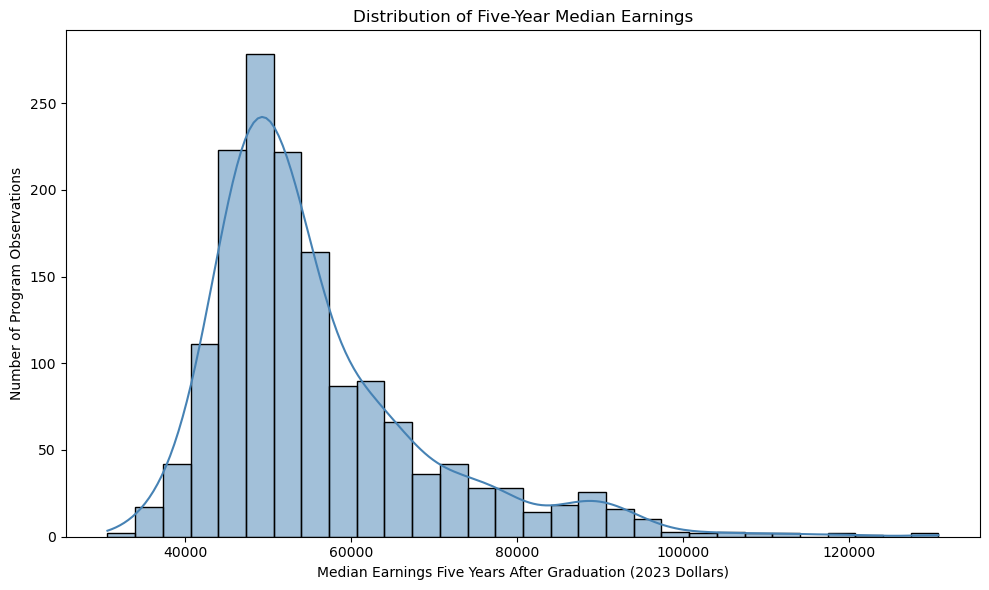

In [7]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=analysis_data,
    x="median_earnings_5yr",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Five-Year Median Earnings")
plt.xlabel("Median Earnings Five Years After Graduation (2023 Dollars)")
plt.ylabel("Number of Program Observations")
plt.tight_layout()

plt.savefig(
    PROJECT_DIR / "images/earnings_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The distribution has a long upper tail. Most observations have substantially lower earnings than the highest program medians; the middle 50% span \$47,119–\$60,837.

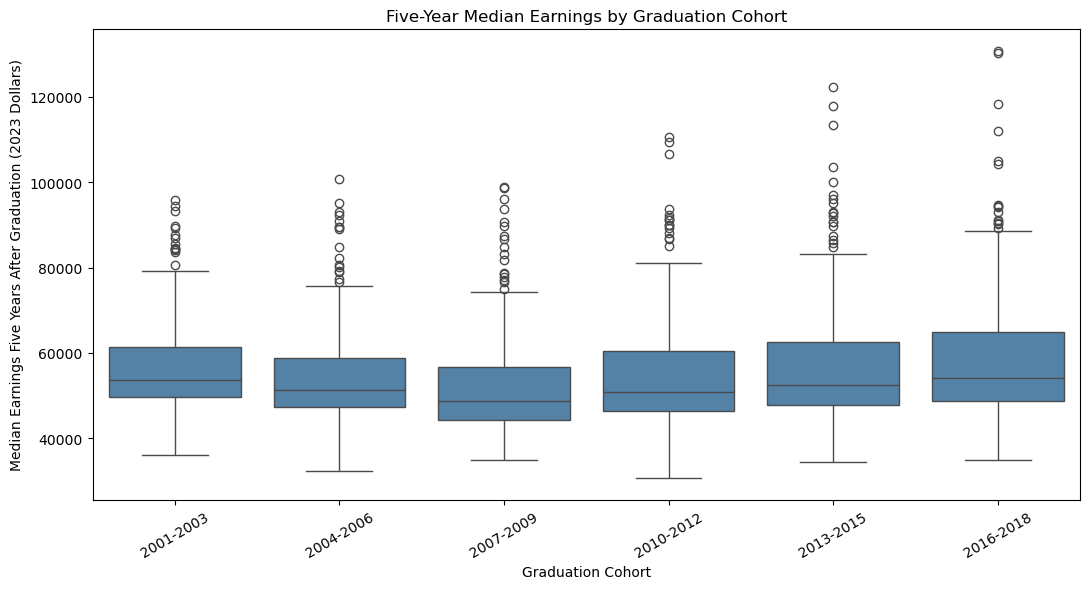

In [8]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=analysis_data,
    x="graduation_cohort",
    y="median_earnings_5yr",
    color="steelblue"
)

plt.title("Five-Year Median Earnings by Graduation Cohort")
plt.xlabel("Graduation Cohort")
plt.ylabel("Median Earnings Five Years After Graduation (2023 Dollars)")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    PROJECT_DIR / "images/earnings_by_cohort.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Median program earnings are lowest for the 2007–2009 cohort and rise in later cohorts. Overlapping boxes show substantial variation within each cohort; these are descriptive differences, not causal estimates.

### Exploratory Findings and Feature Choices

Earnings are right-skewed: the median program observation is \$51,975, with the middle half from \$47,119 to \$60,837 and a range of \$30,647–\$130,776. The upper tail makes RMSE useful alongside MAE; these rows are retained rather than treated as errors.

Cohort medians decline to 2007–2009 and then rise. The boxplots overlap substantially, so cohort is not sufficient on its own and the pattern does not establish a historical cause. Field is the baseline because it describes the training area; institution and cohort test whether school context and graduation timing add predictive information.

Representation is uneven: degree fields have 1–91 observations and institutions have 6–139. Sparse categories may be harder to predict. Because the outcome is continuous, class imbalance is not applicable; uneven category coverage and rare high earnings are the relevant concerns.

## 5. Training and Testing Strategy

The original split uses 80% of rows for training (1,229) and 20% for testing (308), with `random_state=42`. Stratifying by graduation cohort keeps cohort representation similar in both sets. This is a random split within participating institutions, not a test on entirely new institutions or future cohorts.

All categorical encoding is fitted inside each pipeline on training rows only. The same split is used for all four models. Later, five-fold cross-validation on all 1,537 rows provides the primary comparison; the initial test set therefore is not an independent final audit after cross-validation and model selection.

In [9]:
# Use 80% of the observations for training and 20% for testing.
train_indices, test_indices = train_test_split(
    analysis_data.index,
    test_size=0.20,
    random_state=42,
    stratify=analysis_data["graduation_cohort"]
)

train_data = analysis_data.loc[train_indices]
test_data = analysis_data.loc[test_indices]

y_train = train_data["median_earnings_5yr"]
y_test = test_data["median_earnings_5yr"]

print("Training observations:", len(train_data))
print("Testing observations:", len(test_data))

Training observations: 1229
Testing observations: 308


## 6. Baseline and Model Development

The **degree-field-only baseline** directly tests how much institution and cohort add beyond knowing the field. Both methods receive identical baseline and expanded feature sets.

- **Multiple linear regression** estimates additive differences between categories. One-hot encoding turns each category into a binary indicator without implying an order. With the intercept and full indicator sets, individual coefficients are not uniquely interpretable; this project evaluates predictions rather than interpreting coefficients.
- **Random forest regression** averages 500 decision trees and can capture interactions between categories. The original `min_samples_leaf=2` reduces reliance on single training observations; `random_state=42` makes the fit reproducible. No hyperparameter search was performed.

No scaling is needed for binary indicators or tree splits, and no target transformation is applied. `handle_unknown="ignore"` lets prediction proceed for unseen labels, but does not establish performance for new institutions. The column transformer selects only the named predictors, excluding the target and graduate count.

In [10]:
def create_pipeline(features, model):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(handle_unknown="ignore"),
                features
            )
        ]
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )


baseline_features = ["degree_field"]

expanded_features = [
    "degree_field",
    "institution",
    "graduation_cohort"
]

models = {
    "Linear Regression - Baseline": create_pipeline(
        baseline_features,
        LinearRegression()
    ),
    
    "Linear Regression - Expanded": create_pipeline(
        expanded_features,
        LinearRegression()
    ),
    
    "Random Forest - Baseline": create_pipeline(
        baseline_features,
        RandomForestRegressor(
            n_estimators=500,
            random_state=42,
            min_samples_leaf=2
        )
    ),
    
    "Random Forest - Expanded": create_pipeline(
        expanded_features,
        RandomForestRegressor(
            n_estimators=500,
            random_state=42,
            min_samples_leaf=2
        )
    )
}

### Initial Test-Set Evaluation

R² measures explained variation relative to a mean-only reference; it is not classification accuracy. MAE is the average absolute dollar error. RMSE is also in dollars but gives more weight to large errors. Higher R² and lower MAE/RMSE indicate better predictions.

In [11]:
results = []

for model_name, model in models.items():
    model.fit(train_data, y_train)
    predictions = model.predict(test_data)

    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    results.append(
        {
            "Model": model_name,
            "R2": r2,
            "MAE": mae,
            "RMSE": rmse
        }
    )

results_df = pd.DataFrame(results)

results_df[
    ["R2", "MAE", "RMSE"]
] = results_df[
    ["R2", "MAE", "RMSE"]
].round(3)

results_df

,Model,R2,MAE,RMSE
0,Linear Regression - Baseline,0.639,5862.852,8030.970
1,Linear Regression - Expanded,0.812,4170.580,5796.160
2,Random Forest - Baseline,0.638,5878.359,8039.808
3,Random Forest - Expanded,0.874,3402.440,4747.440


### Initial Test-Set Results

Adding institution and cohort improves test-set R² from 0.639 to 0.812 for linear regression and from 0.638 to 0.874 for random forest. The expanded random forest has MAE of approximately \$3,402 and RMSE of \$4,747 on this split. These are initial test-set results, separate from the primary five-fold cross-validation estimates below.

In [12]:
improvement_results = pd.DataFrame(
    {
        "Method": [
            "Multiple Linear Regression",
            "Random Forest Regression"
        ],
        "R2_increase": [
            results_df.loc[1, "R2"] - results_df.loc[0, "R2"],
            results_df.loc[3, "R2"] - results_df.loc[2, "R2"]
        ],
        "MAE_reduction": [
            results_df.loc[0, "MAE"] - results_df.loc[1, "MAE"],
            results_df.loc[2, "MAE"] - results_df.loc[3, "MAE"]
        ],
        "RMSE_reduction": [
            results_df.loc[0, "RMSE"] - results_df.loc[1, "RMSE"],
            results_df.loc[2, "RMSE"] - results_df.loc[3, "RMSE"]
        ]
    }
)

improvement_results = improvement_results.round(3)
improvement_results

,Method,R2_increase,MAE_reduction,RMSE_reduction
0,Multiple Linear Regression,0.173,1692.272,2234.810
1,Random Forest Regression,0.236,2475.919,3292.368


## 7. Interpreting the Expanded Random Forest

The expanded random forest is the final selected model based on the cross-validation comparison below. For interpretation, use its existing fit on the initial training subset and predictions on the 308-row test subset. The diagonal in the next plot represents a perfect prediction.

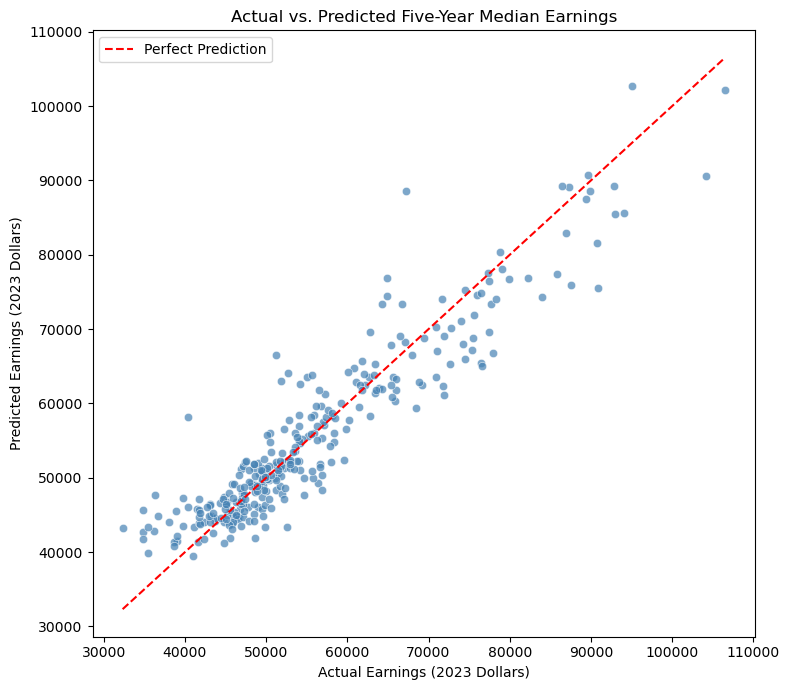

In [13]:
best_model = models["Random Forest - Expanded"]

best_predictions = best_model.predict(test_data)

plt.figure(figsize=(8, 7))

sns.scatterplot(
    x=y_test,
    y=best_predictions,
    alpha=0.7,
    color="steelblue"
)

minimum_value = min(y_test.min(), best_predictions.min())
maximum_value = max(y_test.max(), best_predictions.max())

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    color="red",
    linestyle="--",
    label="Perfect Prediction"
)

plt.title("Actual vs. Predicted Five-Year Median Earnings")
plt.xlabel("Actual Earnings (2023 Dollars)")
plt.ylabel("Predicted Earnings (2023 Dollars)")
plt.legend()
plt.tight_layout()

plt.savefig(
    PROJECT_DIR / "images/random_forest_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Points nearer the diagonal have smaller errors. Predictions for some of the highest-earning observations fall below the line, suggesting underprediction in the upper tail. This plot uses the initial test subset, not out-of-fold predictions from cross-validation.

### Permutation Feature Importance

Each original feature is shuffled in the 308-row test set 20 times. The mean decrease in R² measures how much the fitted model relies on that feature. This evaluates original columns, rather than summing tree importance across one-hot indicators. It measures predictive reliance, not a causal effect or a percentage share of earnings.

In [14]:
X_test_expanded = test_data[expanded_features]

importance = permutation_importance(
    best_model,
    X_test_expanded,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="r2"
)

importance_df = pd.DataFrame(
    {
        "Feature": expanded_features,
        "Importance": importance.importances_mean
    }
).sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
0,degree_field,1.416808
1,institution,0.470615
2,graduation_cohort,0.041327


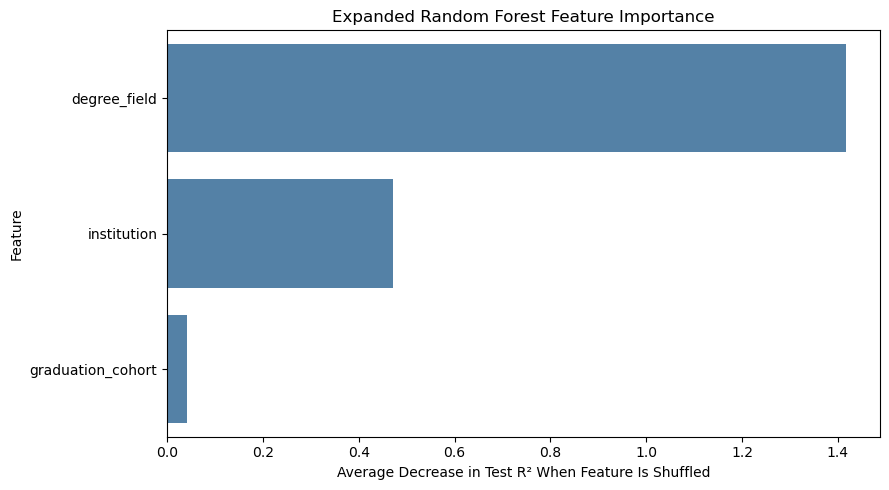

In [15]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    color="steelblue"
)

plt.title("Expanded Random Forest Feature Importance")
plt.xlabel("Average Decrease in Test R² When Feature Is Shuffled")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    PROJECT_DIR / "images/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Shuffling degree field reduces test R² by about 1.417, compared with 0.471 for institution and 0.041 for cohort. Importance can exceed 1 because shuffling can make R² negative. These values are neither percentages nor additive causal contributions.

## 8. Five-Fold Cross-Validation: Primary Model Comparison

The original shuffled `KFold(n_splits=5, random_state=42)` evaluates each model on the same five held-out folds. Each observation is evaluated once, and preprocessing is refitted within each training fold to prevent encoding leakage. MAE and RMSE scorers return negative values by scikit-learn convention; the code changes their signs for reporting.

Cross-validation runs sequentially (`n_jobs=1`) to avoid the original environment's multiprocessing shutdown errors. This changes execution scheduling only, not the folds, algorithms, seeds, or model parameters. Metrics are arithmetic means across folds; R² standard deviation describes fold-to-fold variation, not a confidence interval.

In [16]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "R2": "r2",
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error"
}

cv_results = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        analysis_data,
        analysis_data["median_earnings_5yr"],
        cv=cv,
        scoring=scoring,
        n_jobs=1
    )

    cv_results.append(
        {
            "Model": model_name,
            "Mean_R2": scores["test_R2"].mean(),
            "Mean_MAE": -scores["test_MAE"].mean(),
            "Mean_RMSE": -scores["test_RMSE"].mean(),
            "R2_Standard_Deviation": scores["test_R2"].std()
        }
    )

cv_results_df = pd.DataFrame(cv_results)

numeric_columns = [
    "Mean_R2",
    "Mean_MAE",
    "Mean_RMSE",
    "R2_Standard_Deviation"
]

cv_results_df[numeric_columns] = (
    cv_results_df[numeric_columns].round(3)
)

cv_results_df

,Model,Mean_R2,Mean_MAE,Mean_RMSE,R2_Standard_Deviation
0,Linear Regression - Baseline,0.579,6075.063,8701.171,0.027
1,Linear Regression - Expanded,0.774,4425.641,6379.239,0.013
2,Random Forest - Baseline,0.577,6073.438,8715.100,0.026
3,Random Forest - Expanded,0.850,3553.461,5197.939,0.013


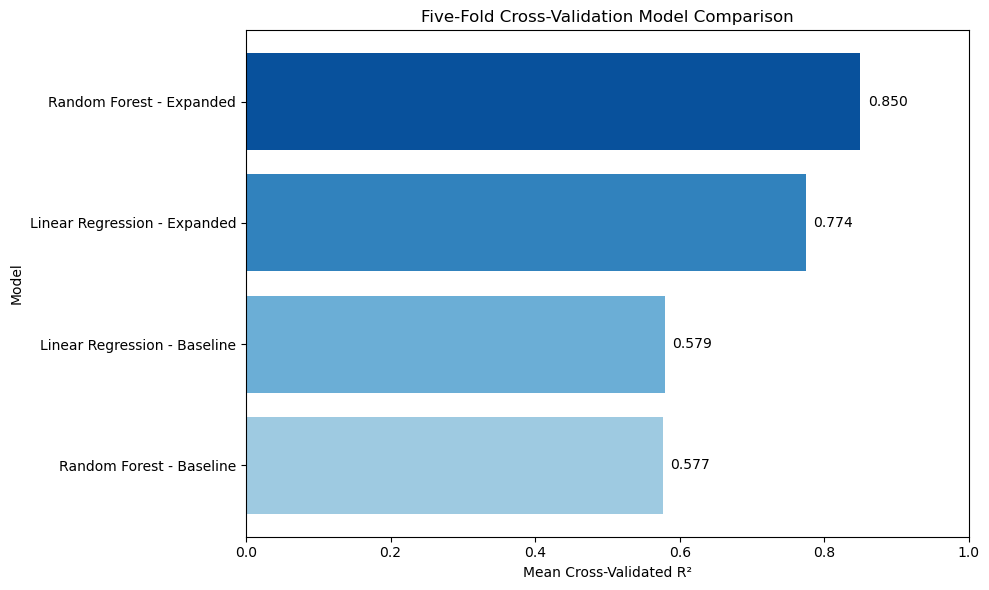

In [17]:
# Compare cross-validated model performance.

plot_data = cv_results_df.sort_values("Mean_R2")

plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_data["Model"],
    plot_data["Mean_R2"],
    color=["#9ecae1", "#6baed6", "#3182bd", "#08519c"]
)

plt.xlabel("Mean Cross-Validated R²")
plt.ylabel("Model")
plt.title("Five-Fold Cross-Validation Model Comparison")
plt.xlim(0, 1)

for bar, value in zip(bars, plot_data["Mean_R2"]):
    plt.text(
        value + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center"
    )

plt.tight_layout()
plt.savefig(
    PROJECT_DIR / "images/cross_validation_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

The expanded models outperform their field-only baselines; expanded random forest has the highest mean R². The chart shows fold means, not uncertainty intervals or individual prediction accuracy.

### Cross-Validation Results and Model Selection

| Model | Mean R² | Mean MAE | Mean RMSE |
| --- | ---: | ---: | ---: |
| Linear regression — baseline | 0.579 | \$6,075 | \$8,701 |
| Linear regression — expanded | 0.774 | \$4,426 | \$6,379 |
| Random forest — baseline | 0.577 | \$6,073 | \$8,715 |
| Random forest — expanded | **0.850** | **\$3,553** | **\$5,198** |

Adding institution and cohort increases mean R² by **0.195** for linear regression and **0.273** for random forest. Random forest MAE falls by approximately \$2,520 (41.5%). The expanded random forest ranks best on all three measures and is the final selected model.

Its mean R² corresponds to about 85.0% explained variation across held-out folds, not 85% accuracy and not a guarantee for a particular student. These are descriptive improvements; no statistical significance test was conducted.

### Export Reproducible Result Tables

Save the computed results alongside the cleaned data. Test-set metrics and cross-validation means remain separate. These exports come from the executed models, not manually entered values.

In [18]:
results_df.to_csv(PROJECT_DIR / "data/test_set_model_results.csv", index=False)
cv_results_df.to_csv(PROJECT_DIR / "data/cross_validation_model_results.csv", index=False)
importance_df.to_csv(PROJECT_DIR / "data/random_forest_feature_importance.csv", index=False)
print("Saved test-set, cross-validation, and permutation-importance tables.")

Saved test-set, cross-validation, and permutation-importance tables.


## 9. Limitations, Ethics, and Reflection

The model estimates aggregate program outcomes, not individual earnings. PSEO covers participating institutions and excludes some employment circumstances; it may not represent every North Carolina institution or graduate. Excluding missing or suppressed earnings can introduce selection bias. Small fields and institutions have limited representation.

Occupation, industry, location, experience, demographics, and student background are omitted. Institution can reflect these differences as well as educational context, so the patterns are **predictive associations, not causal effects**. Shuffling a feature does not identify the effect of changing a student's college or major.

Random validation shares many institutions across training and evaluation folds. Performance may be optimistic for entirely unseen institutions; treating cohorts categorically also does not validate forecasts for future cohorts. The initial test set participates in the later full-data cross-validation, so neither model selection nor interpretation constitutes a new untouched external evaluation.

Incorrect predictions could mislead students choosing programs or institutions. Use this work as an exploratory tool alongside costs, interests, completion prospects, and other evidence—not as the sole basis for educational or financial decisions. Earnings do not measure the full social or personal value of education.

The most useful next steps would be validation with entire institutions held out, a chronological cohort evaluation, and error comparisons for sparse fields and high-earning programs. Those checks are future work, not completed results.

## 10. Conclusion

Institution and cohort substantially improve predictions beyond degree field alone. The expanded random forest is selected with five-fold mean R² of 0.850, MAE of \$3,553, and RMSE of \$5,198. Degree field has the strongest permutation importance, institution is meaningful, and cohort has a smaller individual contribution. This supports a richer prediction model while leaving causal and individual-level questions unanswered.

## 11. Code and AI Transparency

See the [project writeup](project.md) for background, APA-style references, and the full narrative, or [view this notebook on GitHub](https://github.com/parsafeizi/Data-Scince-Portfolio/blob/main/projects/nc-graduate-earnings/nc_graduate_earnings_analysis.ipynb).

I used OpenAI ChatGPT/Codex to assist with brainstorming, code troubleshooting, explaining Python and scikit-learn methods, organizing the analysis, and improving writing. I reviewed the code and outputs and remain responsible for the analysis. No specific AI model version is claimed.